In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
plt.style.use("ggplot")

In [2]:
df = pd.read_csv("../Data/Telco_Customer_Churn_Dataset.csv")

df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [3]:
seg_df = df[["tenure", "MonthlyCharges", "Contract", "Churn"]]

seg_df.head()

,tenure,MonthlyCharges,Contract,Churn
0,1,29.85,Month-to-month,No
1,34,56.95,One year,No
2,2,53.85,Month-to-month,Yes
3,45,42.30,One year,No
4,2,70.70,Month-to-month,Yes


In [4]:
# Convert Contract column into numeric values

seg_df["Contract"] = seg_df["Contract"].map({
    "Month-to-month": 0,
    "One year": 1,
    "Two year": 2
})

seg_df.head()

C:\Users\aadhi\AppData\Local\Temp\ipykernel_1772\262300219.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  seg_df["Contract"] = seg_df["Contract"].map({


,tenure,MonthlyCharges,Contract,Churn
0,1,29.85,0,No
1,34,56.95,1,No
2,2,53.85,0,Yes
3,45,42.30,1,No
4,2,70.70,0,Yes


In [5]:
# Select features for clustering

X = seg_df[["tenure", "MonthlyCharges", "Contract"]]

X.head()

,tenure,MonthlyCharges,Contract
0,1,29.85,0
1,34,56.95,1
2,2,53.85,0
3,45,42.30,1
4,2,70.70,0


In [6]:
# Standardize the features

scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)

print(X_scaled[:5])

[[-1.27744458 -1.16032292 -0.8282069 ]
 [ 0.06632742 -0.25962894  0.37127103]
 [-1.23672422 -0.36266036 -0.8282069 ]
 [ 0.51425142 -0.74653546  0.37127103]
 [-1.23672422  0.19736523 -0.8282069 ]]


In [7]:
# Apply K-Means Clustering

kmeans = KMeans(n_clusters=3, random_state=42)

seg_df["Cluster"] = kmeans.fit_predict(X_scaled)

seg_df.head()

C:\Users\aadhi\AppData\Local\Temp\ipykernel_1772\2425236190.py:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  seg_df["Cluster"] = kmeans.fit_predict(X_scaled)


,tenure,MonthlyCharges,Contract,Churn,Cluster
0,1,29.85,0,No,2
1,34,56.95,1,No,2
2,2,53.85,0,Yes,2
3,45,42.30,1,No,0
4,2,70.70,0,Yes,1


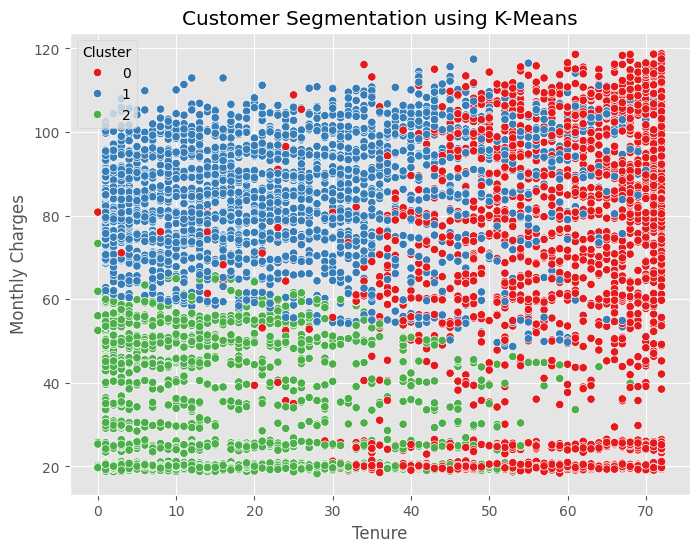

In [8]:
plt.figure(figsize=(8,6))

sns.scatterplot(
    data=seg_df,
    x="tenure",
    y="MonthlyCharges",
    hue="Cluster",
    palette="Set1"
)

plt.title("Customer Segmentation using K-Means")
plt.xlabel("Tenure")
plt.ylabel("Monthly Charges")

plt.show()

In [9]:
# Calculate churn rate for each customer segment

churn_analysis = pd.crosstab(
    seg_df["Cluster"],
    seg_df["Churn"],
    normalize="index"
) * 100

print(churn_analysis.round(2))

Churn       No    Yes
Cluster              
0        93.42   6.58
1        53.17  46.83
2        77.56  22.44


<Figure size 800x500 with 0 Axes>

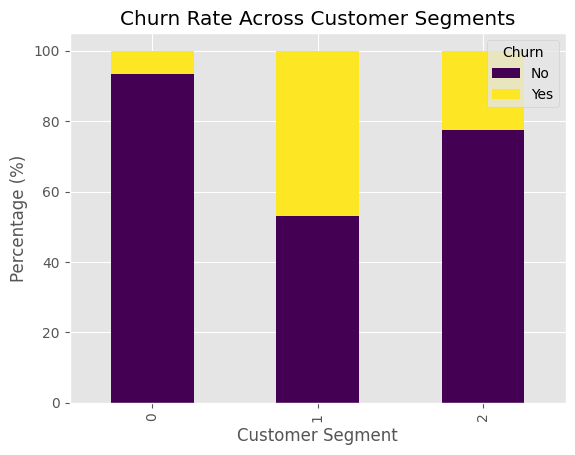

In [10]:
plt.figure(figsize=(8,5))

churn_analysis.plot(
    kind="bar",
    stacked=True,
    colormap="viridis"
)

plt.title("Churn Rate Across Customer Segments")
plt.xlabel("Customer Segment")
plt.ylabel("Percentage (%)")
plt.legend(title="Churn")

plt.show()

In [11]:
segment_summary = seg_df.groupby("Cluster")[["tenure", "MonthlyCharges"]].mean()

print(segment_summary)

            tenure  MonthlyCharges
Cluster                           
0        59.498065       69.879140
1        22.551391       84.075473
2        14.276322       33.150865


# 📊 Task 3: Customer Segmentation

## Observation

Customer segmentation was successfully performed using the K-Means clustering algorithm. Customers were grouped based on tenure, monthly charges, and contract type. Before clustering, categorical data was converted into numeric format and the features were standardized to improve clustering performance.

The resulting clusters showed different customer characteristics. Churn rates were analyzed across these segments, helping identify which customer groups were more likely to discontinue the service.

## Conclusion

Task 3 successfully segmented customers into meaningful groups based on their service usage and contract information. The analysis provided valuable insights into customer behavior and churn patterns, which can help businesses design targeted marketing strategies and improve customer retention.